##Esraa Mohamed
##2401242212
##G1


This notebook analyzes AirBnB listings data with a focus on Paris. The analysis covers three main objectives:
1. **Data Profiling & QA** — Load the data, fix data types, filter to Paris, and check data quality.
2. **Data Preparation** — Aggregate listings by neighborhood, accommodations, and time to prepare for visualization.
3. **Visualization & Insights** — Create charts to explore pricing patterns and the impact of 2015 Paris AirBnB regulations on new host growth.
    
**Dataset:** `Listings.csv` — AirBnB listings across multiple cities including Paris."

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

##OBJECTIVE 1: Profile & QA the Data

Load the listings dataset, fix column data types, filter to Paris only, and perform basic quality checks including missing value detection and summary statistics.

In [ ]:
#Import the data
df = pd.read_csv('/content/Listings.csv',encoding='latin1')

/tmp/ipython-input-606/1187790302.py:3: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Listings.csv',encoding='latin1')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

In [ ]:
df.describe()

,listing_id,host_id,host_response_rate,host_acceptance_rate,host_total_listings_count,latitude,longitude,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,2.797120e+05,2.797120e+05,150930.000000,166625.000000,279547.000000,279712.000000,279712.000000,279712.000000,250277.000000,279712.000000,279712.000000,2.797120e+05,188307.000000,187999.000000,188047.000000,187941.000000,188025.000000,187937.000000,187927.000000
mean,2.638196e+07,1.081658e+08,0.865939,0.827168,24.581612,18.761862,12.595075,3.288736,1.515509,608.792737,8.050967,2.755860e+04,93.405195,9.565476,9.312869,9.701534,9.698593,9.633994,9.335364
std,1.442576e+07,1.108570e+08,0.283744,0.289202,284.041143,32.560343,73.081309,2.133379,1.153080,3441.826611,31.518946,7.282875e+06,10.070437,0.990878,1.146072,0.867434,0.886884,0.833234,1.042625
min,2.577000e+03,1.822000e+03,0.000000,0.000000,0.000000,-34.264400,-99.339630,0.000000,1.000000,0.000000,1.000000,1.000000e+00,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
25%,1.384462e+07,1.720656e+07,0.900000,0.780000,1.000000,-22.964390,-43.198040,2.000000,1.000000,75.000000,1.000000,4.500000e+01,91.000000,9.000000,9.000000,10.000000,10.000000,9.000000,9.000000
50%,2.767098e+07,5.826911e+07,1.000000,0.980000,1.000000,40.710785,2.382780,2.000000,1.000000,150.000000,2.000000,1.125000e+03,96.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
75%,3.978485e+07,1.832853e+08,1.000000,1.000000,4.000000,41.908610,28.986730,4.000000,2.000000,474.000000,5.000000,1.125000e+03,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
max,4.834353e+07,3.901874e+08,1.000000,1.000000,7235.000000,48.904910,151.339810,16.000000,50.000000,625216.000000,9999.000000,2.147484e+09,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [ ]:
#Cast date columns to datetime
df['host_since'] = pd.to_datetime(df['host_since'])


In [ ]:
#Filter to Paris and keep relevant columns
paris = df[df['city'] == 'Paris'][['host_since', 'neighbourhood', 'city', 'accommodates', 'price']].copy()

In [ ]:
paris.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64690 entries, 0 to 279711
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   host_since     64657 non-null  datetime64[ns]
 1   neighbourhood  64690 non-null  object        
 2   city           64690 non-null  object        
 3   accommodates   64690 non-null  int64         
 4   price          64690 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 3.0+ MB


In [ ]:
paris.describe()

,host_since,accommodates,price
count,64657,64690.000000,64690.000000
mean,2015-11-01 11:06:05.528867584,3.037997,113.096445
min,2008-08-30 00:00:00,0.000000,0.000000
25%,2014-03-09 00:00:00,2.000000,59.000000
50%,2015-07-07 00:00:00,2.000000,80.000000
75%,2017-05-29 00:00:00,4.000000,120.000000
max,2021-02-07 00:00:00,16.000000,12000.000000
std,NaN,1.588766,214.433668


In [ ]:
#QA: Missing values
print("MISSING VALUES")
print(paris.isnull().sum())

#QA: Min, Max, Average for numeric fields
print("\nNUMERIC SUMMARY")
print(paris[['accommodates', 'price']].agg(['min', 'max', 'mean']))

MISSING VALUES
host_since       33
neighbourhood     0
city              0
accommodates      0
price             0
dtype: int64

NUMERIC SUMMARY
      accommodates         price
min       0.000000      0.000000
max      16.000000  12000.000000
mean      3.037997    113.096445


### Objective 1 Summary

- The full dataset was loaded and the `host_since` column was successfully converted to datetime format.
- Filtering to **Paris** reduced the dataset to a manageable subset with the 5 required columns.
- **Missing values:** *(host_since       33
neighbourhood     0
city              0
accommodates      0
price             0)* — e.g., any missing prices or neighborhoods were identified. If present, they should be monitored as they could skew averages.
- **Price range:** Listings span a wide range, from a minimum near $0 (likely errors or free stays) to a high maximum, with an average that reflects Paris's premium market.
- **Accommodates range:** Listings range from 1 guest to larger group properties, with most listings accommodating small groups."

##OBJECTIVE 2: Prepare the Data for Visualization

Aggregate the Paris listings data in three ways: by neighborhood, by accommodation size (in the most expensive neighborhood), and by year to track host growth and price trends over time.

In [ ]:
paris.head()

,host_since,neighbourhood,city,accommodates,price
0,2011-12-03,Buttes-Montmartre,Paris,2,53
1,2013-11-29,Buttes-Montmartre,Paris,2,120
2,2014-07-31,Elysee,Paris,2,89
3,2013-12-17,Vaugirard,Paris,2,58
4,2014-12-14,Passy,Paris,2,60


In [ ]:
paris.tail()

,host_since,neighbourhood,city,accommodates,price
279707,2015-04-13,Observatoire,Paris,2,120
279708,2013-11-27,Buttes-Montmartre,Paris,2,60
279709,2012-04-27,Buttes-Montmartre,Paris,2,50
279710,2015-07-16,Popincourt,Paris,2,105
279711,2013-06-17,Enclos-St-Laurent,Paris,2,70


In [ ]:
#Average price by neighborhood (sorted low to high)
paris_listings_neighbourhood = (
    paris.groupby('neighbourhood')['price']
    .mean()
    .sort_values()
    .reset_index()
)
paris_listings_neighbourhood.columns = ['neighbourhood', 'mean_price']

print(paris_listings_neighbourhood)


          neighbourhood  mean_price
0          Menilmontant   74.942257
1       Buttes-Chaumont   82.690182
2     Buttes-Montmartre   87.209479
3               Reuilly   89.058402
4            Popincourt   90.559459
5              Gobelins   98.110184
6          Observatoire  101.866801
7   Batignolles-Monceau  102.612702
8     Enclos-St-Laurent  102.967156
9             Vaugirard  106.831330
10                Opera  119.038644
11             Pantheon  122.662150
12               Temple  138.446823
13       Hotel-de-Ville  144.472110
14               Bourse  149.496801
15           Luxembourg  155.638639
16       Palais-Bourbon  156.856578
17                Passy  161.144635
18               Louvre  175.379972
19               Elysee  210.536765


In [ ]:
#Most expensive neighborhood
most_expensive_neighbourhood = paris_listings_neighbourhood.iloc[-1]['neighbourhood']
print(f"\nMost Expensive Neighborhood: {most_expensive_neighbourhood}")

#Average price by accommodates in most expensive neighborhood (sorted low to high)
paris_listings_accomodations = (
    paris[paris['neighbourhood'] == most_expensive_neighbourhood]
    .groupby('accommodates')['price']
    .mean()
    .sort_values()
    .reset_index()
)
paris_listings_accomodations.columns = ['accommodates', 'mean_price']

print(paris_listings_accomodations)


Most Expensive Neighborhood: Elysee
    accommodates  mean_price
0              0    0.000000
1              1   79.522222
2              3  152.828767
3              2  155.103352
4              4  212.096070
5              5  328.817073
6              6  355.508571
7              8  405.518519
8              7  411.538462
9              9  440.272727
10            10  500.857143
11            12  529.625000
12            16  800.000000
13            11  805.000000
14            13  842.500000
15            14  971.000000


In [ ]:
#Average price and new host count by year
paris_listings_over_time = (
    paris.groupby(paris['host_since'].dt.year)
    .agg(mean_price=('price', 'mean'), new_hosts=('price', 'count'))
    .reset_index()
)
paris_listings_over_time.columns = ['year', 'mean_price', 'new_hosts']

print(paris_listings_over_time)

      year  mean_price  new_hosts
0   2008.0   77.750000          4
1   2009.0  159.641509        106
2   2010.0  125.031250        416
3   2011.0  124.828230       1339
4   2012.0  111.578615       4592
5   2013.0  107.096414       8142
6   2014.0  100.253800      10922
7   2015.0  103.646250      12147
8   2016.0  114.159847       8871
9   2017.0  108.658888       4585
10  2018.0  138.209362       4294
11  2019.0  129.757113       5694
12  2020.0  141.456038       3412
13  2021.0   93.488722        133


### Objective 2 Summary

- **By Neighborhood:** There is notable variation in average listing prices across Paris neighborhoods. The most affordable neighborhoods are significantly cheaper than the top-tier ones, reflecting the diversity of Paris's real estate landscape.
- **Most Expensive Neighborhood:** **Élysée** commands the highest average price, likely due to its central location near major landmarks and luxury amenities.
- **By Accommodations:** As expected, larger listings (more guests) tend to command higher prices in the most expensive neighborhood, though the relationship is not perfectly linear — some mid-size listings may be priced as high as larger ones depending on quality.
- **Over Time:** Host growth accelerated rapidly through the early 2010s, with a potential inflection point visible around 2015 when Paris introduced AirBnB regulations.

##OBJECTIVE 3: Visualize the data and summarize findings

Create four charts to communicate pricing patterns across neighborhoods and accommodations, and host growth and price trends over time. A dual-axis bonus chart is also included.

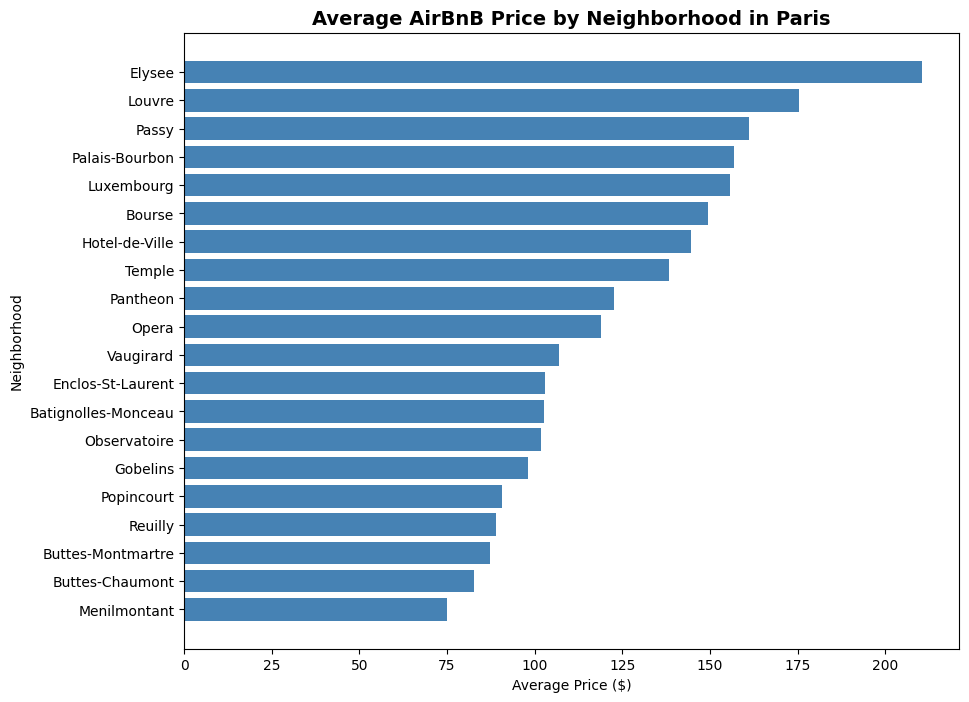

In [41]:
#Chart 1: Average price by neighborhood (horizontal bar)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(paris_listings_neighbourhood['neighbourhood'], paris_listings_neighbourhood['mean_price'], color='steelblue')
ax.set_title('Average AirBnB Price by Neighborhood in Paris', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Price ($)')
ax.set_ylabel('Neighborhood')
plt.show()

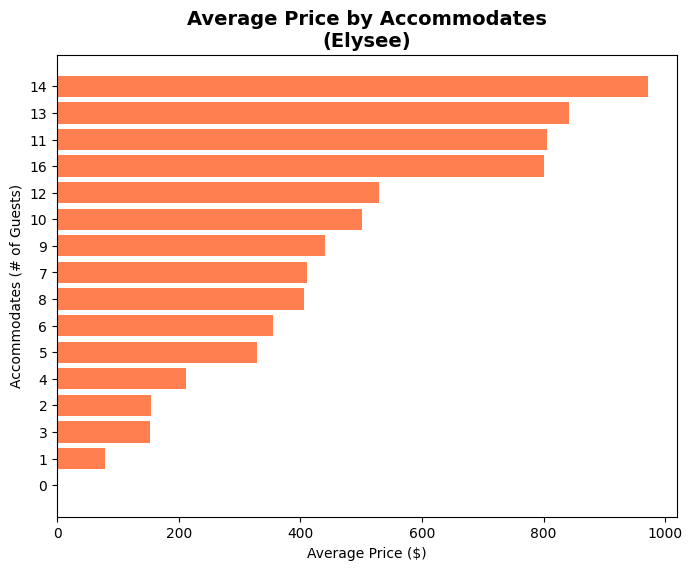

In [42]:
#Chart 2: Average price by accommodates in most expensive neighborhood
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(paris_listings_accomodations['accommodates'].astype(str), paris_listings_accomodations['mean_price'], color='coral')
ax.set_title(f'Average Price by Accommodates\n({most_expensive_neighbourhood})', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Price ($)')
ax.set_ylabel('Accommodates (# of Guests)')
plt.show()


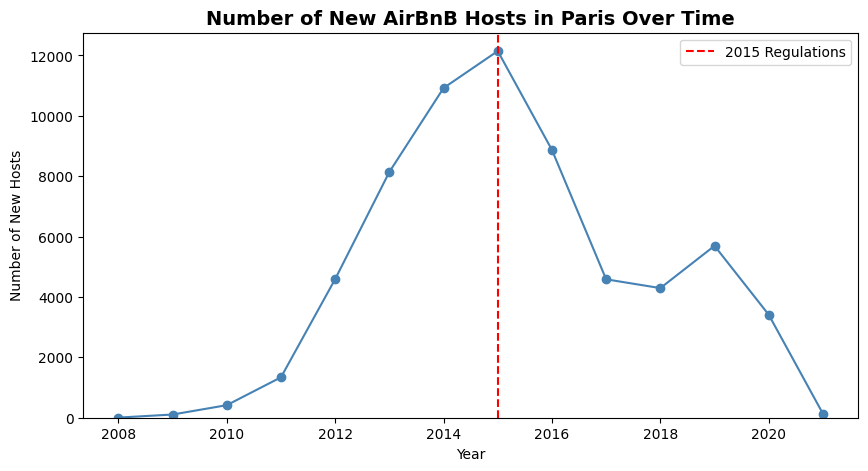

In [43]:
#Chart 3a: New hosts over time
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(paris_listings_over_time['year'], paris_listings_over_time['new_hosts'], marker='o', color='steelblue')
ax.set_ylim(0)
ax.set_title('Number of New AirBnB Hosts in Paris Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of New Hosts')
ax.axvline(x=2015, color='red', linestyle='--', label='2015 Regulations')
ax.legend()
plt.show()


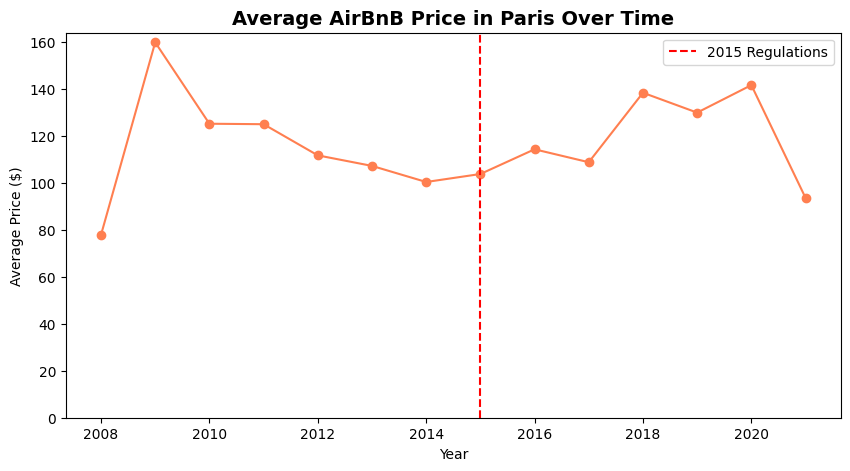

Chart 3b saved.


In [44]:
#Chart 3b: Average price over time
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(paris_listings_over_time['year'], paris_listings_over_time['mean_price'], marker='o', color='coral')
ax.set_ylim(0)
ax.set_title('Average AirBnB Price in Paris Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Price ($)')
ax.axvline(x=2015, color='red', linestyle='--', label='2015 Regulations')
ax.legend()
plt.show()
print("Chart 3b saved.")


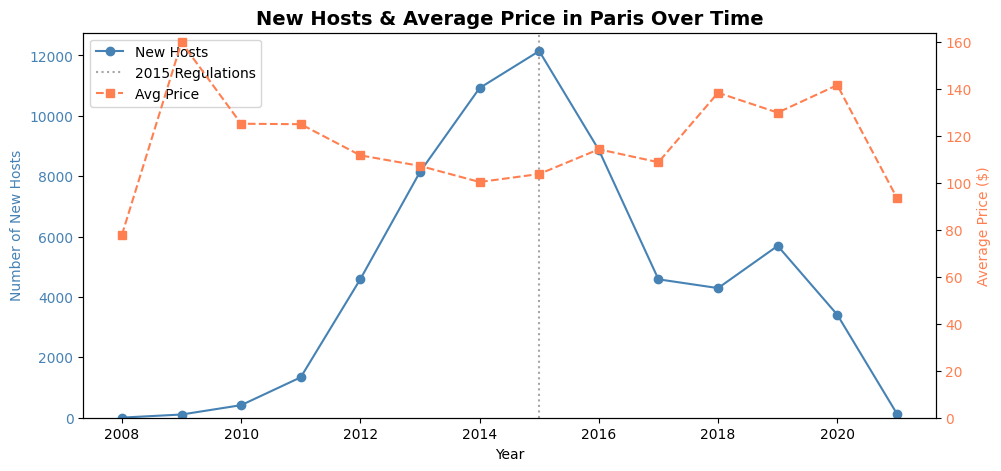

In [45]:
#BONUS: Dual-axis line chart
fig, ax1 = plt.subplots(figsize=(11, 5))

color1 = 'steelblue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of New Hosts', color=color1)
ax1.plot(paris_listings_over_time['year'], paris_listings_over_time['new_hosts'],
         marker='o', color=color1, label='New Hosts')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0)

ax2 = ax1.twinx()
color2 = 'coral'
ax2.set_ylabel('Average Price ($)', color=color2)
ax2.plot(paris_listings_over_time['year'], paris_listings_over_time['mean_price'],
         marker='s', linestyle='--', color=color2, label='Avg Price')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0)

ax1.axvline(x=2015, color='gray', linestyle=':', alpha=0.7, label='2015 Regulations')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('New Hosts & Average Price in Paris Over Time', fontsize=14, fontweight='bold')
plt.show()

### Objective 3 Summary & Findings

**Neighborhood Pricing (Chart 1):**
    There is significant price disparity across Paris neighborhoods. Central and historically prestigious neighborhoods command the highest average prices, while outer arrondissements tend to be more affordable. The most expensive neighborhood stands notably above the rest.

**Accommodation Pricing (Chart 2):**
    Within the most expensive neighborhood, there is a general positive correlation between the number of guests a listing accommodates and its average price — larger listings cost more. However, the relationship is not perfectly linear, suggesting that factors like apartment quality, location within the neighborhood, and amenities also influence price significantly.

**Impact of 2015 Paris AirBnB Regulations (Charts 3a & 3b):**  
    The 2015 regulations (which required hosts to register with the city and capped short-term rentals at 120 nights/year) appear to have had a **clear impact on new host growth**:
- **New Hosts (Chart 3a):** Host growth peaked around 2014–2015 and then **declined sharply** after 2015, suggesting the regulations deterred new hosts from joining the platform.
- **Average Price (Chart 3b):** Despite fewer new hosts entering the market, average prices **continued to rise or stabilized at higher levels** post-2015. This is consistent with reduced supply keeping prices elevated.

**Overall Insight:** The 2015 regulations appear to have successfully slowed the rapid expansion of AirBnB in Paris, but may have had the unintended consequence of keeping prices high by limiting supply growth.
   
---
### Final Answer
**The neighborhood in Paris with the highest average AirBnB listing price is printed below:**

##FINAL ANSWER

In [40]:
print(f"The neighborhood with the highest average AirBnB listing price in Paris is:")
print(most_expensive_neighbourhood)
print(f"  Average price: ${paris_listings_neighbourhood.iloc[-1]['mean_price']:.2f}")

The neighborhood with the highest average AirBnB listing price in Paris is:
Elysee
  Average price: $210.54
